In [197]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from pyprojroot import here

import sys
sys.path.append(str(here("Scripts")))
from utils import sort_data

In [198]:
data_path = here("Data/FPL_data_tidy.parquet")
data = pd.read_parquet(data_path)

In [199]:
data.head()

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,match_date,opp,gf,ga,sh,sht,corners,yc,rc,fouls,b365_win,b365_draw,b365_loss,b365_o25,b365_u25,b365_ah_line,b365_ah_team,b365_ah_opp
0,Aaron Anselmino,DEF,Chelsea,1.8,0,0,0,0,0.0,774,242,0,0,0.0,0.0,0,5,0,0,0,0,0,0,0,3,0,0,0,0,0,40,False,0,25,2024-25,0.0,0.0,0.0,0.0,0,2025-02-14,Brighton,0,3,8,0,9,2,0,15,2.45,3.6,2.7,1.57,2.38,-0.25,2.08,1.73
1,Aaron Anselmino,DEF,Chelsea,0.5,0,0,0,0,0.0,774,252,0,0,0.0,0.0,0,2,0,0,0,0,0,156,1,2,0,0,82,92,10,40,False,0,26,2024-25,0.0,0.0,0.0,0.0,0,2025-02-22,Aston Villa,1,2,15,7,3,3,0,16,2.6,3.4,2.63,1.57,2.38,-0.0,1.92,1.98
2,Aaron Anselmino,DEF,Chelsea,1.0,0,0,0,0,0.0,774,268,0,0,0.0,0.0,0,17,0,0,0,0,0,236,0,4,0,0,29,58,29,40,True,0,27,2024-25,0.0,0.0,0.0,0.0,0,2025-02-25,Southampton,4,0,19,10,4,1,0,6,1.17,8.0,13.0,1.29,3.75,-2.25,2.0,1.93
3,Aaron Anselmino,DEF,Chelsea,0.5,0,0,0,0,0.0,774,273,0,0,0.0,0.0,0,11,0,0,0,0,0,325,0,1,0,0,21,52,31,40,True,0,28,2024-25,0.0,0.0,0.0,0.0,0,2025-03-09,Leicester,1,0,20,7,12,1,0,12,1.18,8.0,12.0,1.33,3.2,-2.0,1.95,1.95
4,Aaron Anselmino,DEF,Chelsea,0.0,0,0,0,0,0.0,774,281,0,0,0.0,0.0,0,1,0,0,0,0,0,436,0,1,0,0,4,31,27,40,False,0,29,2024-25,0.0,0.0,0.0,0.0,0,2025-03-16,Arsenal,0,1,8,2,4,3,0,13,4.5,3.6,1.8,1.86,1.92,0.75,1.84,2.06


In [200]:
cols_to_lag = [
    "total_points", "minutes", "goals_scored", "assists", "bonus", "bps",
    "clean_sheets", "creativity", "goals_conceded", "ict_index",
    "influence", "own_goals", "penalties_missed", "penalties_saved",
    "red_cards", "saves", "threat", "yellow_cards", "starts",
    "expected_assists", "expected_goal_involvements", "expected_goals",
    "expected_goals_conceded", "team_h_score", "team_a_score",
    'gf', 'ga', 'sh', 'sht', 'corners', 'yc', 'rc', 'fouls'
]

cols_id = [
    'name', 'position', 'team', 'element', 'fixture',
    'opponent_team', 'was_home', 'gw', 'season_id',
    'match_date', 'opp'
]

cols_fpl_market = [
    'xp', 'selected', 'transfers_balance',
    'transfers_in', 'transfers_out', 'value'
]

cols_betting = [
    'b365_win', 'b365_draw', 'b365_loss',
    'b365_o25', 'b365_u25', 'b365_ah_line',
    'b365_ah_team', 'b365_ah_opp'
]


In [201]:
data.shape[1] == len(cols_to_lag + cols_id + cols_fpl_market + cols_betting)

True

In [202]:
def ema(df:pd.DataFrame,
        cols_to_lag:list[str] | None,
        window_size:int=4)->tuple[pd.DataFrame, list[str]]:

    if cols_to_lag is None:
        return df.copy(), []

    df = df.sort_values(by=["name", "match_date", "gw", "season_id"]).reset_index(drop=True)

    ema_frame = df.groupby(["name", "season_id"])[cols_to_lag].transform(lambda x: x.ewm(span=window_size, adjust=False).mean().shift(1))

    new_cols = [f"{c}_ema_{window_size}" for c in cols_to_lag]
    df[new_cols] = ema_frame.fillna(0)
    return df, new_cols


In [203]:
def lagged_features(df:pd.DataFrame,
                    cols_to_lag:list[str] | None,
                    lag_size:int=1)->tuple[pd.DataFrame, list[str]]:
    if cols_to_lag is None:
        return df.copy(), []
    df = df.sort_values(by=["name", "match_date", "gw", "season_id"]).reset_index(drop=True)
    lagged_frame = df.groupby(["name", "season_id"])[cols_to_lag].transform(lambda x: x.shift(lag_size))
    new_cols = [f"{c}_lagged_{lag_size}" for c in cols_to_lag]
    df[new_cols] = lagged_frame.fillna(0)

    return df.drop(columns=cols_to_lag), new_cols

In [204]:
data_ema, ema_cols = ema(df=data,
                        cols_to_lag=cols_to_lag,
                        window_size=4)


In [205]:
data.shape

(127465, 58)

In [206]:
data_ema.shape

(127465, 91)

In [207]:
data_lagged, lagged_cols = lagged_features(df=data_ema,
                        cols_to_lag=cols_to_lag+cols_fpl_market)


In [208]:
data_lagged.shape

(127465, 91)

In [209]:
data.shape[1] + 2*len(cols_to_lag) - len(cols_to_lag)

91

In [210]:
data_lagged.head()

,name,position,team,element,fixture,opponent_team,was_home,gw,season_id,match_date,opp,b365_win,b365_draw,b365_loss,b365_o25,b365_u25,b365_ah_line,b365_ah_team,b365_ah_opp,total_points_ema_4,minutes_ema_4,goals_scored_ema_4,assists_ema_4,bonus_ema_4,bps_ema_4,clean_sheets_ema_4,creativity_ema_4,goals_conceded_ema_4,ict_index_ema_4,influence_ema_4,own_goals_ema_4,penalties_missed_ema_4,penalties_saved_ema_4,red_cards_ema_4,saves_ema_4,threat_ema_4,yellow_cards_ema_4,starts_ema_4,expected_assists_ema_4,expected_goal_involvements_ema_4,expected_goals_ema_4,expected_goals_conceded_ema_4,team_h_score_ema_4,team_a_score_ema_4,gf_ema_4,ga_ema_4,sh_ema_4,sht_ema_4,corners_ema_4,yc_ema_4,rc_ema_4,fouls_ema_4,total_points_lagged_1,minutes_lagged_1,goals_scored_lagged_1,assists_lagged_1,bonus_lagged_1,bps_lagged_1,clean_sheets_lagged_1,creativity_lagged_1,goals_conceded_lagged_1,ict_index_lagged_1,influence_lagged_1,own_goals_lagged_1,penalties_missed_lagged_1,penalties_saved_lagged_1,red_cards_lagged_1,saves_lagged_1,threat_lagged_1,yellow_cards_lagged_1,starts_lagged_1,expected_assists_lagged_1,expected_goal_involvements_lagged_1,expected_goals_lagged_1,expected_goals_conceded_lagged_1,team_h_score_lagged_1,team_a_score_lagged_1,gf_lagged_1,ga_lagged_1,sh_lagged_1,sht_lagged_1,corners_lagged_1,yc_lagged_1,rc_lagged_1,fouls_lagged_1,xp_lagged_1,selected_lagged_1,transfers_balance_lagged_1,transfers_in_lagged_1,transfers_out_lagged_1,value_lagged_1
0,Aaron Anselmino,DEF,Chelsea,774,242,5,False,25,2024-25,2025-02-14,Brighton,2.45,3.6,2.7,1.57,2.38,-0.25,2.08,1.73,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0
1,Aaron Anselmino,DEF,Chelsea,774,252,2,False,26,2024-25,2025-02-22,Aston Villa,2.6,3.4,2.63,1.57,2.38,-0.0,1.92,1.98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000,0.000,0.000,3.000,8.000,0.000,9.000,2.000,0.0,15.000,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,3,0,0,3,8,0,9,2,0,15,1.8,0,0,0,0,40
2,Aaron Anselmino,DEF,Chelsea,774,268,17,True,27,2024-25,2025-02-25,Southampton,1.17,8.0,13.0,1.29,3.75,-2.25,2.0,1.93,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.600,0.400,0.400,2.600,10.800,2.800,6.600,2.400,0.0,15.400,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,2,1,1,2,15,7,3,3,0,16,0.5,156,82,92,10,40
3,Aaron Anselmino,DEF,Chelsea,774,273,11,True,28,2024-25,2025-03-09,Leicester,1.18,8.0,12.0,1.33,3.2,-2.0,1.95,1.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.160,0.240,1.840,1.560,14.080,5.680,5.560,1.840,0.0,11.640,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,4,0,4,0,19,10,4,1,0,6,1.0,236,29,58,29,40
4,Aaron Anselmino,DEF,Chelsea,774,281,1,False,29,2024-25,2025-03-16,Arsenal,4.5,3.6,1.8,1.86,1.92,0.75,1.84,2.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.296,0.144,1.504,0.936,16.448,6.208,8.136,1.504,0.0,11.784,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1,0,1,0,20,7,12,1,0,12,0.5,325,21,52,31,40


In [211]:
def odds_into_probs(df: pd.DataFrame, cols_betting: list[str] | None = None) -> tuple[pd.DataFrame, list[str]]:
    if cols_betting is None:
        return df.copy(), []

    df = df.copy()
    new_prob_cols = []
    for col in cols_betting:
        prob_col = col.replace("b365", "prob")
        df[prob_col] = (1 / df[col]).fillna(0).replace([np.inf, -np.inf], 0)
        new_prob_cols.append(prob_col)

    return df.drop(columns=cols_betting), new_prob_cols

In [212]:
data_lagged, prob_cols = odds_into_probs(df=data_lagged, cols_betting=cols_betting)
prob_cols


['prob_win',
 'prob_draw',
 'prob_loss',
 'prob_o25',
 'prob_u25',
 'prob_ah_line',
 'prob_ah_team',
 'prob_ah_opp']

In [213]:
len(prob_cols) == len(cols_betting)

True

In [214]:
data_lagged[prob_cols].head()

,prob_win,prob_draw,prob_loss,prob_o25,prob_u25,prob_ah_line,prob_ah_team,prob_ah_opp
0,0.408163,0.277778,0.37037,0.636943,0.420168,-4.0,0.480769,0.578035
1,0.384615,0.294118,0.380228,0.636943,0.420168,0.0,0.520833,0.505051
2,0.854701,0.125,0.076923,0.775194,0.266667,-0.444444,0.5,0.518135
3,0.847458,0.125,0.083333,0.75188,0.3125,-0.5,0.512821,0.512821
4,0.222222,0.277778,0.555556,0.537634,0.520833,1.333333,0.543478,0.485437


In [216]:
for col in prob_cols:
    data_lagged[col] = data_lagged[col].clip(0, 1)

In [217]:
data_lagged.head()

,name,position,team,element,fixture,opponent_team,was_home,gw,season_id,match_date,opp,total_points_ema_4,minutes_ema_4,goals_scored_ema_4,assists_ema_4,bonus_ema_4,bps_ema_4,clean_sheets_ema_4,creativity_ema_4,goals_conceded_ema_4,ict_index_ema_4,influence_ema_4,own_goals_ema_4,penalties_missed_ema_4,penalties_saved_ema_4,red_cards_ema_4,saves_ema_4,threat_ema_4,yellow_cards_ema_4,starts_ema_4,expected_assists_ema_4,expected_goal_involvements_ema_4,expected_goals_ema_4,expected_goals_conceded_ema_4,team_h_score_ema_4,team_a_score_ema_4,gf_ema_4,ga_ema_4,sh_ema_4,sht_ema_4,corners_ema_4,yc_ema_4,rc_ema_4,fouls_ema_4,total_points_lagged_1,minutes_lagged_1,goals_scored_lagged_1,assists_lagged_1,bonus_lagged_1,bps_lagged_1,clean_sheets_lagged_1,creativity_lagged_1,goals_conceded_lagged_1,ict_index_lagged_1,influence_lagged_1,own_goals_lagged_1,penalties_missed_lagged_1,penalties_saved_lagged_1,red_cards_lagged_1,saves_lagged_1,threat_lagged_1,yellow_cards_lagged_1,starts_lagged_1,expected_assists_lagged_1,expected_goal_involvements_lagged_1,expected_goals_lagged_1,expected_goals_conceded_lagged_1,team_h_score_lagged_1,team_a_score_lagged_1,gf_lagged_1,ga_lagged_1,sh_lagged_1,sht_lagged_1,corners_lagged_1,yc_lagged_1,rc_lagged_1,fouls_lagged_1,xp_lagged_1,selected_lagged_1,transfers_balance_lagged_1,transfers_in_lagged_1,transfers_out_lagged_1,value_lagged_1,prob_win,prob_draw,prob_loss,prob_o25,prob_u25,prob_ah_line,prob_ah_team,prob_ah_opp
0,Aaron Anselmino,DEF,Chelsea,774,242,5,False,25,2024-25,2025-02-14,Brighton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0.408163,0.277778,0.37037,0.636943,0.420168,0.0,0.480769,0.578035
1,Aaron Anselmino,DEF,Chelsea,774,252,2,False,26,2024-25,2025-02-22,Aston Villa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000,0.000,0.000,3.000,8.000,0.000,9.000,2.000,0.0,15.000,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,3,0,0,3,8,0,9,2,0,15,1.8,0,0,0,0,40,0.384615,0.294118,0.380228,0.636943,0.420168,0.0,0.520833,0.505051
2,Aaron Anselmino,DEF,Chelsea,774,268,17,True,27,2024-25,2025-02-25,Southampton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.600,0.400,0.400,2.600,10.800,2.800,6.600,2.400,0.0,15.400,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,2,1,1,2,15,7,3,3,0,16,0.5,156,82,92,10,40,0.854701,0.125,0.076923,0.775194,0.266667,0.0,0.5,0.518135
3,Aaron Anselmino,DEF,Chelsea,774,273,11,True,28,2024-25,2025-03-09,Leicester,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.160,0.240,1.840,1.560,14.080,5.680,5.560,1.840,0.0,11.640,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,4,0,4,0,19,10,4,1,0,6,1.0,236,29,58,29,40,0.847458,0.125,0.083333,0.75188,0.3125,0.0,0.512821,0.512821
4,Aaron Anselmino,DEF,Chelsea,774,281,1,False,29,2024-25,2025-03-16,Arsenal,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.296,0.144,1.504,0.936,16.448,6.208,8.136,1.504,0.0,11.784,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1,0,1,0,20,7,12,1,0,12,0.5,325,21,52,31,40,0.222222,0.277778,0.555556,0.537634,0.520833,1.0,0.543478,0.485437


In [221]:
data_lagged["total_points"] = data.total_points

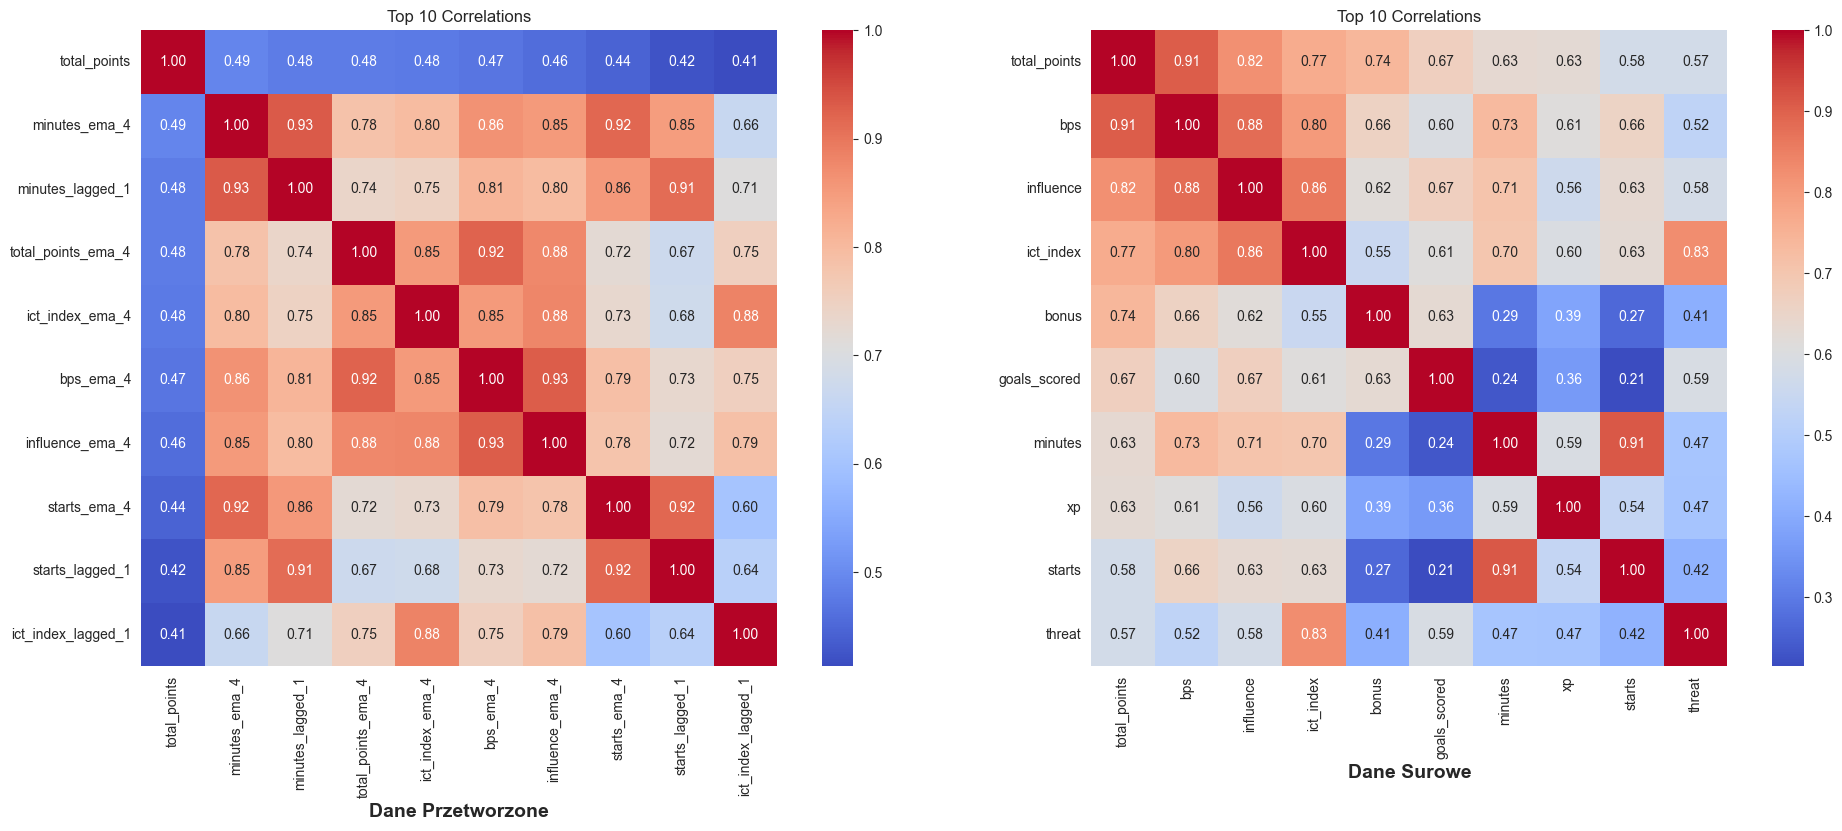

In [236]:
def corr_heatmaps(frames: list[pd.DataFrame], titles: list[str]) -> plt.Figure:
    fig, axes = plt.subplots(1, len(frames), figsize=(10 * len(frames), 8))
    if len(frames) == 1: axes = [axes]

    for ax, df, title in zip(axes, frames, titles):
        top_cols = df.select_dtypes(include=np.number).corr()["total_points"].abs().nlargest(10).index

        sns.heatmap(df[top_cols].corr(), annot=True, cmap="coolwarm", ax=ax,
                    square=True, fmt=".2f")

        ax.set_yticklabels(ax.get_yticklabels(), rotation=0) # Etykiety Y poziomo
        ax.set_title(f"Top 10 Correlations")
        ax.set_xlabel(title, fontsize=14, fontweight='bold') # Podpis pod wykresem

    plt.tight_layout()
    return fig

fig = corr_heatmaps([data_lagged, data], ["Dane Przetworzone", "Dane Surowe"])

In [246]:
def over_corr_pairs(df: pd.DataFrame, threshold: float = 0.9) -> list[tuple[str, str, float]]:
    corr_matrix = df.select_dtypes(include=np.number).corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    pairs = []
    for col in upper_tri.columns:
        correlated_with = upper_tri[col][upper_tri[col] > threshold]
        for idx, val in correlated_with.items():
            pairs.append((idx, col, round(val, 4)))

    return pairs

# for p in pairs: print(f"{p[0]} <-> {p[1]}: {p[2]}")

In [248]:
pairs = over_corr_pairs(data_lagged, 0.9)
pairs

[('fixture', 'gw', 0.9804),
 ('total_points_ema_4', 'bps_ema_4', 0.924),
 ('bps_ema_4', 'influence_ema_4', 0.9297),
 ('minutes_ema_4', 'starts_ema_4', 0.9196),
 ('expected_goal_involvements_ema_4', 'expected_goals_ema_4', 0.9251),
 ('minutes_ema_4', 'minutes_lagged_1', 0.9325),
 ('total_points_lagged_1', 'bps_lagged_1', 0.9087),
 ('saves_ema_4', 'saves_lagged_1', 0.9171),
 ('starts_ema_4', 'starts_lagged_1', 0.919),
 ('minutes_lagged_1', 'starts_lagged_1', 0.9111),
 ('prob_win', 'prob_loss', 0.9689),
 ('prob_o25', 'prob_u25', 0.9904),
 ('prob_ah_team', 'prob_ah_opp', 0.9154)]

In [249]:
for col1, col2, _ in pairs:
    if col1 in data_lagged.columns and col2 in data_lagged.columns:
        data_lagged.drop(columns=col1, inplace=True)

In [251]:
data_lagged.shape

(127465, 80)

In [252]:
data_lagged.head()

,name,position,team,element,opponent_team,was_home,gw,season_id,match_date,opp,goals_scored_ema_4,assists_ema_4,bonus_ema_4,clean_sheets_ema_4,creativity_ema_4,goals_conceded_ema_4,ict_index_ema_4,influence_ema_4,own_goals_ema_4,penalties_missed_ema_4,penalties_saved_ema_4,red_cards_ema_4,threat_ema_4,yellow_cards_ema_4,expected_assists_ema_4,expected_goals_ema_4,expected_goals_conceded_ema_4,team_h_score_ema_4,team_a_score_ema_4,gf_ema_4,ga_ema_4,sh_ema_4,sht_ema_4,corners_ema_4,yc_ema_4,rc_ema_4,fouls_ema_4,goals_scored_lagged_1,assists_lagged_1,bonus_lagged_1,bps_lagged_1,clean_sheets_lagged_1,creativity_lagged_1,goals_conceded_lagged_1,ict_index_lagged_1,influence_lagged_1,own_goals_lagged_1,penalties_missed_lagged_1,penalties_saved_lagged_1,red_cards_lagged_1,saves_lagged_1,threat_lagged_1,yellow_cards_lagged_1,starts_lagged_1,expected_assists_lagged_1,expected_goal_involvements_lagged_1,expected_goals_lagged_1,expected_goals_conceded_lagged_1,team_h_score_lagged_1,team_a_score_lagged_1,gf_lagged_1,ga_lagged_1,sh_lagged_1,sht_lagged_1,corners_lagged_1,yc_lagged_1,rc_lagged_1,fouls_lagged_1,xp_lagged_1,selected_lagged_1,transfers_balance_lagged_1,transfers_in_lagged_1,transfers_out_lagged_1,value_lagged_1,prob_draw,prob_loss,prob_u25,prob_ah_line,prob_ah_opp,total_points
0,Aaron Anselmino,DEF,Chelsea,774,5,False,25,2024-25,2025-02-14,Brighton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0.277778,0.37037,0.420168,0.0,0.578035,0
1,Aaron Anselmino,DEF,Chelsea,774,2,False,26,2024-25,2025-02-22,Aston Villa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000,0.000,0.000,3.000,8.000,0.000,9.000,2.000,0.0,15.000,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,3,0,0,3,8,0,9,2,0,15,1.8,0,0,0,0,40,0.294118,0.380228,0.420168,0.0,0.505051,0
2,Aaron Anselmino,DEF,Chelsea,774,17,True,27,2024-25,2025-02-25,Southampton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.600,0.400,0.400,2.600,10.800,2.800,6.600,2.400,0.0,15.400,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,2,1,1,2,15,7,3,3,0,16,0.5,156,82,92,10,40,0.125,0.076923,0.266667,0.0,0.518135,0
3,Aaron Anselmino,DEF,Chelsea,774,11,True,28,2024-25,2025-03-09,Leicester,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.160,0.240,1.840,1.560,14.080,5.680,5.560,1.840,0.0,11.640,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,4,0,4,0,19,10,4,1,0,6,1.0,236,29,58,29,40,0.125,0.083333,0.3125,0.0,0.512821,0
4,Aaron Anselmino,DEF,Chelsea,774,1,False,29,2024-25,2025-03-16,Arsenal,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.296,0.144,1.504,0.936,16.448,6.208,8.136,1.504,0.0,11.784,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1,0,1,0,20,7,12,1,0,12,0.5,325,21,52,31,40,0.277778,0.555556,0.520833,1.0,0.485437,0


In [257]:
len(data_lagged.team.unique()) == len(data_lagged.opp.unique())

True

In [262]:
filename = "../../Data/FPL_data.parquet"
data_lagged.to_parquet(filename,
                engine='pyarrow',
                index=False)